In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import matplotlib.pyplot as plt
from scripts.constants import *
from scripts.hamiltonian import *

In [ ]:
def bdg_self_consistency(H, U, V, V_prime, 
                         T, max_iter=100,
                         atol=1e-6, rtol=1e-4,
                         with_corr = False):
        flag = False
        num_sites = H.lattice.num_sites
        Nx = H.lattice.X
        Ny = H.lattice.Y

        F0 = cp.zeros(num_sites, dtype=cp.complex128)
        Fx_plus = 0.1 * np.ones(Nx - 1, dtype=np.complex128)
        Fx_min  = -0.1 * np.ones(Nx - 1, dtype=np.complex128)
        Fy_plus = 0.1j * np.ones(Nx, dtype=np.complex128)
        Fy_min  = -0.1j * np.ones(Nx, dtype=np.complex128)

        for iteration in range(max_iter): 
            eigval, eigvec = H.diagonalize(drop_matrix=False)
            eigvec = eigvec[:, eigval >= 0]
            eigval = eigval[eigval >= 0]
            f_E = fermi_dirac(eigval, T)
            u = eigvec[0::4, :]#.reshape((Nx,Ny,-1))
            v = eigvec[1::4, :]#.reshape((Nx,Ny,-1))
            w = eigvec[2::4, :]#.reshape((Nx,Ny,-1))
            x = eigvec[3::4, :]#.reshape((Nx,Ny,-1))


In [3]:
t = 1
mu = -1.8* t
gap_0 = 0.0
gap_p= cp.array([0.1, 0.0j]) * t
gap_s = 0.5 *  t
X,Y = 200,1
U = 1.5 * t
V = 1.5 * t
lattice = Lattice(X, Y, pbc_x=False, pbc_y=False)
H = Hamiltonian(lattice)
block = cp.zeros((4, 4), dtype=cp.complex128)
for i in range(lattice.num_sites):
    block[:,:]=0
    block[:2, :2] = -mu * s0
    block[2:, 2:] = mu * s0
    block[:2, 2:] = -1j * gap_0 * s2
    block[2:, :2] = (-1j * gap_0 * s2).conj().T
    H.set_block(i,i, block)
    # H.set_gap(gap_0,i)

for i, j in lattice.edges:
    block[:,:]=0
    block[0:2, 0:2] = -t * s0
    block[2:4, 2:4] = t * s0

    gap_ij = unconventional_gap(lattice.get_disp(i,j),gap_s = gap_s)
    block[0:2, 2:4] = gap_ij
    gap_ji = unconventional_gap(lattice.get_disp(j,i),gap_s = gap_s)
    block[2:4, 0:2] = gap_ji.conj().T

    H.set_block(i,j, block)
# H.gap_s = cp.ones(lattice.num_sites, dtype=cp.complex128) * 0.1
print(cp.allclose(H.matrix, H.matrix.conj().T, rtol=1e-6, atol=1e-6))


True


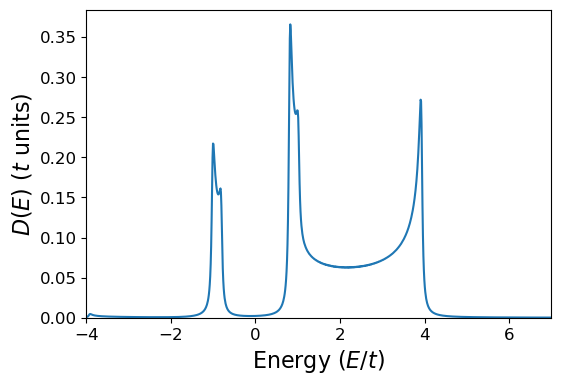

In [4]:
energies = cp.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.03, drop_matrix=False)
plt.figure(figsize=(6,4))
plt.plot(cp.asnumpy(energies), cp.asnumpy(dos_values))
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()